# 1. EDA #

### Importamos las librerias necesarias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## Analisis de variables categoricas

Tenemos la data, veremos que tanto afecta cada variable categorica con nuestro target

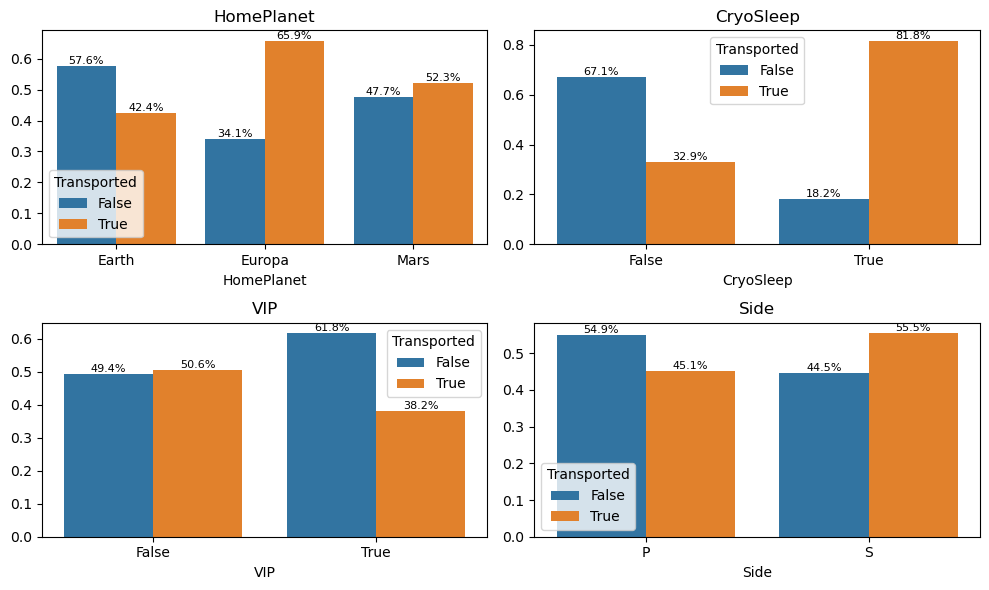

In [3]:
df[['Deck','Num','Side']] = df['Cabin'].str.split('/', expand=True)

categorical_vars = ['HomePlanet', 'CryoSleep', 'VIP', 'Side']

fig, axes = plt.subplots(2, 2, figsize=(10, 6))  

axes = axes.flatten()

for i, var in enumerate(categorical_vars):
    
    plot_df = df.groupby([var, 'Transported']).size().reset_index(name='count')
    plot_df['percentage'] = plot_df.groupby(var)['count'].transform(lambda x: x / x.sum())
    
    ax = sns.barplot(data=plot_df, x=var, y='percentage', hue='Transported', ax=axes[i])
    
    for p in ax.patches:
        height = p.get_height()
        if height > 0.01:
            ax.annotate(f'{height:.1%}', 
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=8)
    
    ax.set_title(var)
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

Se analizaron las principales variables categóricas (HomePlanet, CryoSleep, VIP y Side) en relación con la variable objetivo Transported, evaluando la proporción de pasajeros transportados en cada categoría.

. **HomePlanet:**

    Se observan diferencias en la proporción de pasajeros transportados entre los planetas. Europa presenta la mayor proporción (~66%), seguida de Mars (~52%) y Earth (~42%). Sin embargo, aunque existe variación, la diferencia no es lo suficientemente marcada como para considerarla un predictor fuerte por sí sola.
    
. **CryoSleep:**

    Esta variable muestra una diferencia altamente significativa. Los pasajeros en CryoSleep tienen una probabilidad mucho mayor de ser transportados (~82%) en comparación con aquellos que no lo están (~33%). Esto indica una fuerte relación con el target, convirtiéndola en una de las variables más relevantes del dataset.
    
. **VIP:**

    Se observa una diferencia moderada. Los pasajeros VIP tienen menor probabilidad de ser transportados (~38%) en comparación con los no VIP (~51%). Esto sugiere cierta relación con el target, aunque no tan fuerte como en el caso de CryoSleep.
    
. **Side:**

    Existe una diferencia moderada entre los lados de la nave. Los pasajeros ubicados en el lado S presentan una mayor probabilidad de ser transportados (~55%) frente a los del lado P (~45%). Aunque la diferencia no es extrema, podría aportar información adicional al modelo.

In [4]:
pd.crosstab(df['CryoSleep'], df['VIP'], normalize='index')

VIP,False,True
CryoSleep,,
False,0.967093,0.032907
True,0.992910,0.007090


In [5]:
pd.crosstab(df['CryoSleep'], df['HomePlanet'], normalize='index')

HomePlanet,Earth,Europa,Mars
CryoSleep,,,
False,0.584384,0.218627,0.196990
True,0.466577,0.307562,0.225861


In [6]:
pd.crosstab(df['CryoSleep'], df['Side'], normalize='index')

Side,P,S
CryoSleep,,
False,0.501407,0.498593
True,0.480867,0.519133


In [7]:
pd.crosstab(df['Side'], df['VIP'], normalize='index')

VIP,False,True
Side,,
P,0.975201,0.024799
S,0.978250,0.021750


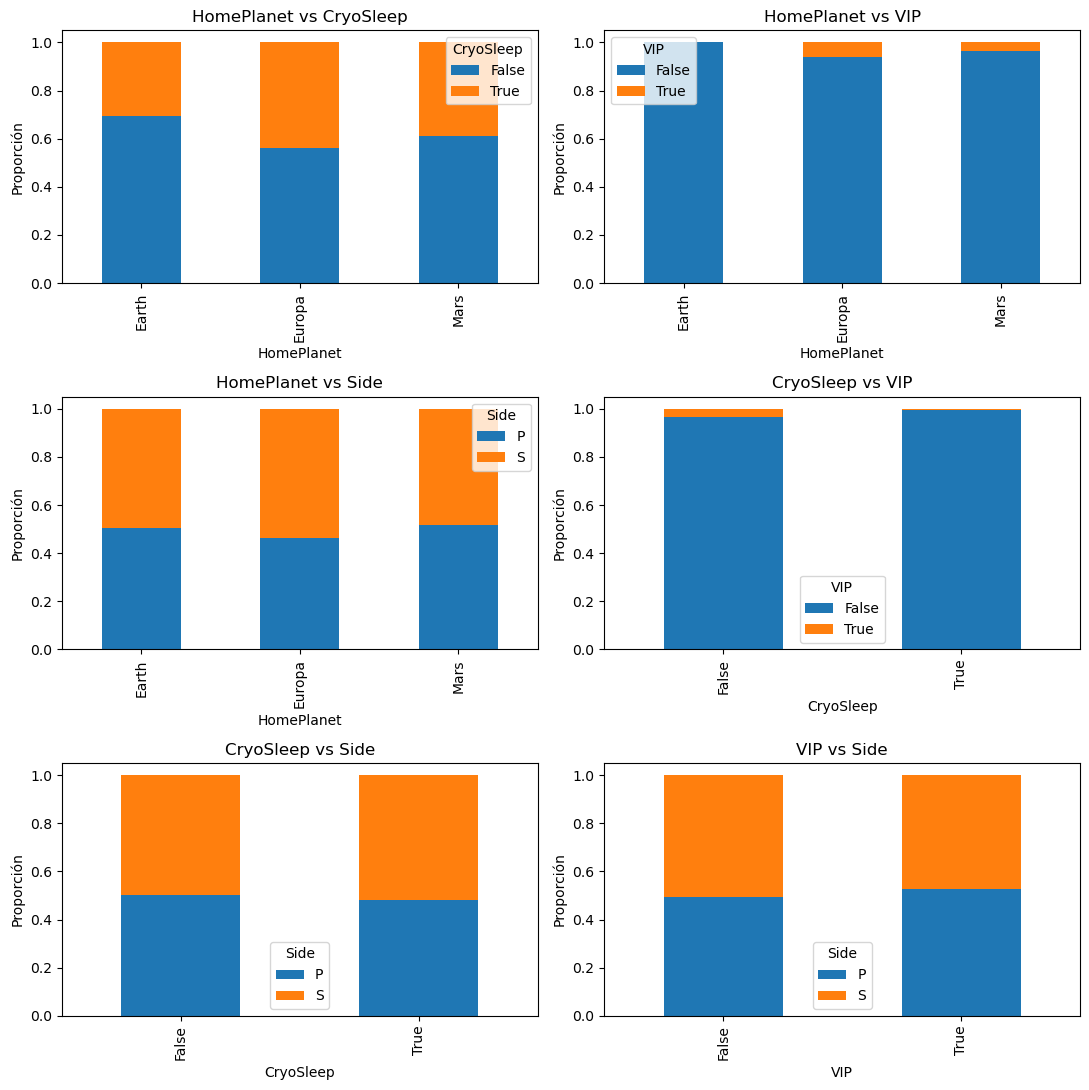

In [8]:
categorical_cols = ['HomePlanet', 'CryoSleep', 'VIP', 'Side']

pairs = [
    ('HomePlanet', 'CryoSleep'),
    ('HomePlanet', 'VIP'),
    ('HomePlanet', 'Side'),
    ('CryoSleep', 'VIP'),
    ('CryoSleep', 'Side'),
    ('VIP', 'Side')
]

fig, axes = plt.subplots(3, 2, figsize=(11, 11))
axes = axes.flatten()

for i, (col1, col2) in enumerate(pairs):
    ct = pd.crosstab(df[col1], df[col2], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i])
    
    axes[i].set_title(f"{col1} vs {col2}")
    axes[i].set_ylabel("Proporción")
    axes[i].set_xlabel(col1)

plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from itertools import combinations

categorical_cols = ['HomePlanet', 'CryoSleep', 'VIP', 'Side']

results = []

for col1, col2 in combinations(categorical_cols, 2):
    table = pd.crosstab(df[col1], df[col2])
    
    chi2, p, dof, expected = chi2_contingency(table)
    
    n = table.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(table.shape)-1)))
    
    results.append({
        'Variable 1': col1,
        'Variable 2': col2,
        'Chi2': chi2,
        'p-value': p,
        "Cramer's V": cramers_v
    })

results_df = pd.DataFrame(results)

# ordenar por fuerza de relación
results_df = results_df.sort_values(by="Cramer's V", ascending=False)

results_df

,Variable 1,Variable 2,Chi2,p-value,Cramer's V
1,HomePlanet,VIP,262.117662,1.207460e-57,0.177795
0,HomePlanet,CryoSleep,116.398433,5.301533e-26,0.118587
3,CryoSleep,VIP,53.754570,2.271651e-13,0.080574
2,HomePlanet,Side,13.661085,1.080272e-03,0.040572
4,CryoSleep,Side,3.125744,7.706470e-02,0.019425
5,VIP,Side,0.720219,3.960722e-01,0.009317


El análisis de proporciones, cbi2 y cramer´s V entre variables categóricas permitió evaluar posibles relaciones y dependencias entre ellas. Se observó que, en general, las diferencias entre categorías no son significativas, lo que sugiere una baja correlación entre estas variables.

Porcentajes permiten explorar visualmente la relación entre variables categóricas, mientras que el test de Chi-cuadrado permite validar si dicha relación es estadísticamente significativa. Finalmente, Cramér’s V permite medir la intensidad de esa relación.

Esto indica que no existe redundancia evidente y que cada variable podría aportar información independiente al modelo. Sin embargo, este resultado no excluye la necesidad de realizar transformaciones o ingeniería de variables en etapas posteriores.

## Analisis de variables numericas

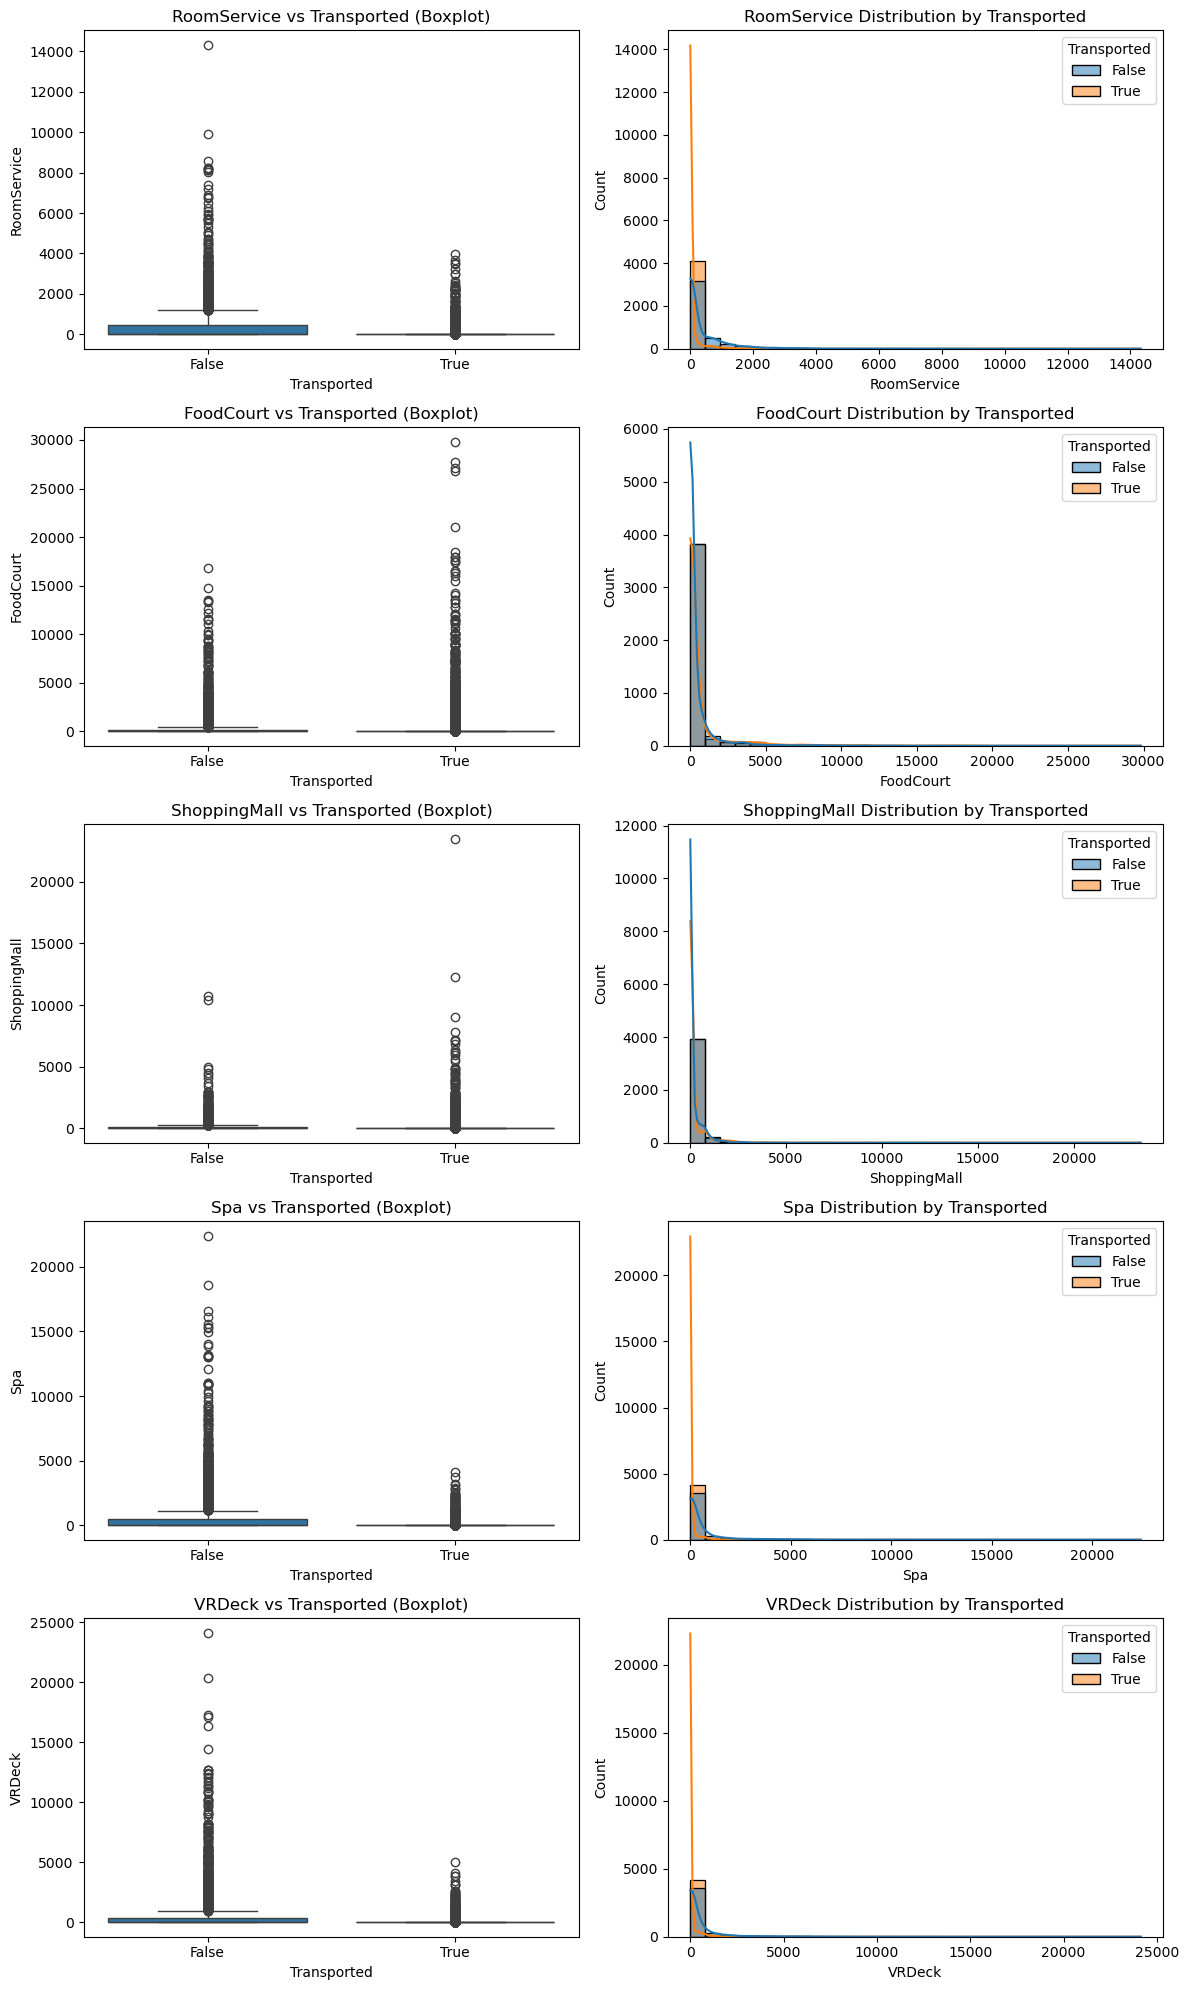

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(12, 20))

for i, col in enumerate(numerical_cols):
    
    # BOXPLOT
    sns.boxplot(data=df, x='Transported', y=col, ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} vs Transported (Boxplot)")
    
    # HISTOGRAMA
    sns.histplot(data=df, x=col, hue='Transported', bins=30, kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(f"{col} Distribution by Transported")

plt.tight_layout()
plt.show()

In [11]:
for col in numerical_cols:
    print(f"\n{col}")
    print(df.groupby('Transported')[col].mean())


RoomService
Transported
False    389.266066
True      63.098021
Name: RoomService, dtype: float64

FoodCourt
Transported
False    382.615930
True     532.691984
Name: FoodCourt, dtype: float64

ShoppingMall
Transported
False    167.566217
True     179.829972
Name: ShoppingMall, dtype: float64

Spa
Transported
False    564.382666
True      61.675531
Name: Spa, dtype: float64

VRDeck
Transported
False    543.629822
True      69.148131
Name: VRDeck, dtype: float64


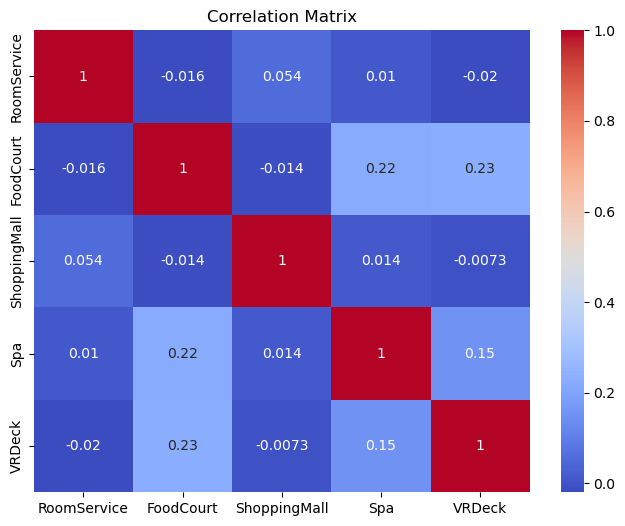

In [12]:
numerical_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
corr = df[numerical_cols].corr()


plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Podemos ver similiar comportamiento de las variables de gastos, pero no estan correlacionadas entre si, por lo que podemos asumir que cada una por separado aporta información al modelo.


# 2. FEATURE ENGINEERING #

Dicho esto, podemos crear una nueva variable de gasto total, ya que, como lo hemos mencionado antes, las variables se comportan similar

In [13]:
df['TotalGastos'] = df[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1)
cols = list(df.columns)

cols.remove('TotalGastos')
cols.insert(cols.index('Transported'), 'TotalGastos')

df = df[cols]
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,TotalGastos,Transported,Deck,Num,Side
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,0.0,False,B,0,P
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,736.0,True,F,0,S
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,10383.0,False,A,0,S
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,5176.0,False,A,0,S
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,1091.0,True,F,1,S


Ahora comparamos la nueva variable **TotalGatos** con el target

In [14]:
df.groupby('Transported')['TotalGastos'].mean()

Transported
False    2004.149247
True      885.689127
Name: TotalGastos, dtype: float64

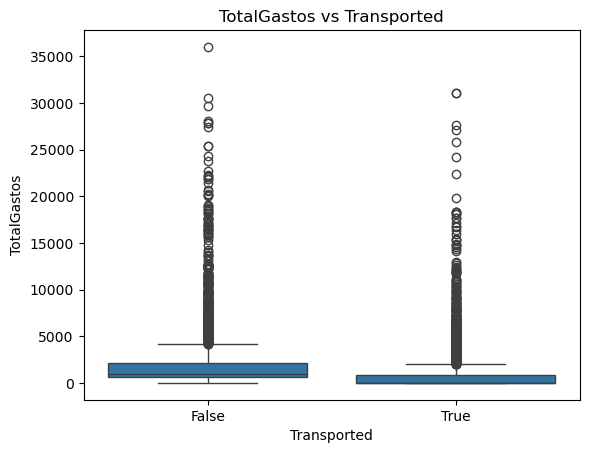

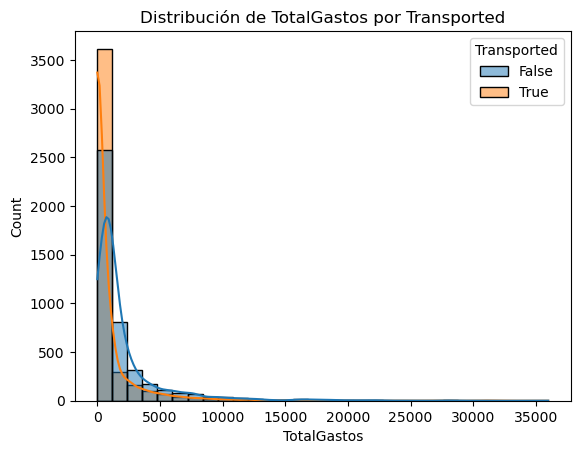

In [15]:
sns.boxplot(data=df, x='Transported', y='TotalGastos')
plt.title("TotalGastos vs Transported")
plt.show()
sns.histplot(data=df, x='TotalGastos', hue='Transported', bins=30, kde=True)
plt.title("Distribución de TotalGastos por Transported")
plt.show()

Se observa que los pasajeros no transportados presentan un gasto total significativamente mayor en comparación con los transportados.

Además, la distribución muestra una fuerte concentración de valores bajos en ambos grupos, pero con una mayor dispersión y presencia de valores extremos en el grupo no transportado.

Esto sugiere una relación inversa entre el gasto total y la probabilidad de ser transportado.

### Creamos una nueva variable para ver si hubo gasto o no ###

In [16]:
df['HasGasto'] = (df['TotalGastos'] > 0).astype(int)

In [17]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,TotalGastos,Transported,Deck,Num,Side,HasGasto
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,0.0,False,B,0,P,0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,736.0,True,F,0,S,1
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,10383.0,False,A,0,S,1
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,5176.0,False,A,0,S,1
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,1091.0,True,F,1,S,1


In [18]:
pd.crosstab(df['HasGasto'], df['Transported'], normalize='index')

Transported,False,True
HasGasto,,
0,0.213523,0.786477
1,0.701389,0.298611


Se observa una relación clara entre el comportamiento de gasto y la variable objetivo. Los pasajeros que no realizaron ningún gasto presentan una alta probabilidad de ser transportados (78%), mientras que aquellos que sí gastaron tienen una mayor probabilidad de no ser transportados (70%).

Esto evidencia una relación inversa entre el consumo y la probabilidad de ser transportado, convirtiendo esta variable en un fuerte predictor del target.

Primero analizaremos si ambas estan correlacionadas 

In [19]:
pd.crosstab(df['CryoSleep'], df['HasGasto'], normalize='index')

HasGasto,0,1
CryoSleep,,
False,0.095238,0.904762
True,1.000000,0.000000


Con esto detectamos que una explica a la otra, ya que si esta en Cryo, definitivamennte no gasta, por lo que lo ideal sera
una variable nueva **Cryo_NoGasto**

In [20]:
df['Cryo_NoGasto'] = ((df['CryoSleep'] == True) & (df['HasGasto'] == 0)).astype(int)
pd.crosstab(df['Cryo_NoGasto'], df['Transported'], normalize='index')

Transported,False,True
Cryo_NoGasto,,
0,0.664958,0.335042
1,0.182417,0.817583


La variable Cryo_NoGasto muestra una fuerte relación con la variable objetivo Transported.
Se observa que cuando Cryo_NoGasto = 1 (pasajeros en CryoSleep sin gastos), aproximadamente el 81.7% fueron transportados, lo que indica una alta probabilidad de éxito.
En contraste, cuando Cryo_NoGasto = 0, la probabilidad de ser transportado cae significativamente (~33.5%).

Ahora eliminamos variables que no sirven como  passenger ID y Cabin que ya la separamos por partes

In [21]:
df = df.drop(columns=['PassengerId', 'Cabin', 'Name'])
df.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,TotalGastos,Transported,Deck,Num,Side,HasGasto,Cryo_NoGasto
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,0.0,False,B,0,P,0,0
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,736.0,True,F,0,S,1,0
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,10383.0,False,A,0,S,1,0
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,5176.0,False,A,0,S,1,0
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,1091.0,True,F,1,S,1,0


In [22]:
df.isnull().sum()

HomePlanet      201
CryoSleep       217
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
TotalGastos       0
Transported       0
Deck            199
Num             199
Side            199
HasGasto          0
Cryo_NoGasto      0
dtype: int64

Ahora hacemos el split para separar el train del test para tratar los NaN y asi evitar Data Leakage

In [23]:
X = df.drop(columns=['Transported'])
y = df['Transported']

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Definimos columnas para realizar la imputacion para:
-  **Numericas:** Utilizamos la mediana ya que hay muchos outliers.
- **Categoricas:** El valor mas frecuente.
- **Booleanas:** El valor mas frecuente.

In [25]:
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalGastos']

cat_cols = ['HomePlanet', 'Destination', 'Deck', 'Side']

bool_cols = ['CryoSleep', 'VIP']

In [26]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

bool_imputer = SimpleImputer(strategy='most_frequent')

X_train[bool_cols] = bool_imputer.fit_transform(X_train[bool_cols])
X_test[bool_cols] = bool_imputer.transform(X_test[bool_cols])

Hacemos el OneHot para las categoricas

In [27]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_test_cat = ohe.transform(X_test[cat_cols])

In [28]:
encoded_cols = ohe.get_feature_names_out(cat_cols)

X_train_cat = pd.DataFrame(X_train_cat, columns=encoded_cols, index=X_train.index)
X_test_cat = pd.DataFrame(X_test_cat, columns=encoded_cols, index=X_test.index)

X_train = X_train.drop(columns=cat_cols)
X_test = X_test.drop(columns=cat_cols)

X_train = pd.concat([X_train, X_train_cat], axis=1)
X_test = pd.concat([X_test, X_test_cat], axis=1)

X_train.head()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,TotalGastos,Num,...,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Side_P,Side_S
3600,False,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0,630,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1262,True,17.0,False,0.0,0.0,0.0,0.0,0.0,0.0,201,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
8612,False,35.0,False,0.0,0.0,0.0,0.0,0.0,0.0,1483,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
5075,True,26.0,False,0.0,0.0,0.0,0.0,0.0,0.0,164,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4758,False,13.0,False,0.0,0.0,60.0,1.0,5147.0,5208.0,818,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [29]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# MODELADO #

Primero hacemos GridSearch para ver los mejores hiperparametros para RANDOM FOREST

In [30]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [8, 12, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

rf = RandomForestClassifier(random_state=42)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
0.8078818095774997


Ahora XG BOOST

In [32]:
param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

In [33]:
!pip install XGboost

In [34]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

grid_xgb = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print(grid_xgb.best_params_)
print(grid_xgb.best_score_)

{'colsample_bytree': 1, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1}
0.8117629778276587


E:\ANACONDA\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:51:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [38]:
from sklearn.metrics import accuracy_score
pred_xgb = grid_xgb.best_estimator_.predict(X_test)

accuracy_score(y_test, pred_xgb)

0.8102357676825762

In [ ]:
import pandas as pd

# cargar test oficial
test_df = pd.read_csv("test.csv")

# guardar ids
passenger_ids = test_df["PassengerId"]

# ========= FEATURE ENGINEERING =========
test_df["TotalGastos"] = (
    test_df["RoomService"] +
    test_df["FoodCourt"] +
    test_df["ShoppingMall"] +
    test_df["Spa"] +
    test_df["VRDeck"]
)

test_df["HasGasto"] = (test_df["TotalGastos"] > 0).astype(int)

test_df[["Deck","Num","Side"]] = test_df["Cabin"].str.split("/", expand=True)

test_df["Cryo_NoGasto"] = (
    (test_df["CryoSleep"] == True) &
    (test_df["TotalGastos"] == 0)
).astype(int)

# eliminar columnas
test_df = test_df.drop(columns=["PassengerId","Cabin","Name"])

In [ ]:
test_df[num_cols] = num_imputer.transform(test_df[num_cols])
test_df[cat_cols] = cat_imputer.transform(test_df[cat_cols])
test_df[bool_cols] = bool_imputer.transform(test_df[bool_cols])

test_cat = ohe.transform(test_df[cat_cols])

encoded_cols = ohe.get_feature_names_out(cat_cols)

test_cat = pd.DataFrame(test_cat, columns=encoded_cols, index=test_df.index)

test_df = test_df.drop(columns=cat_cols)

test_df = pd.concat([test_df, test_cat], axis=1)

# igualar columnas exactas
test_df = test_df.reindex(columns=X_train.columns, fill_value=0)

test_df = test_df.astype(float)

In [ ]:
pred_kaggle = grid_xgb.best_estimator_.predict(test_df)

In [ ]:
submission = pd.DataFrame({
    "PassengerId": passenger_ids,
    "Transported": pred_kaggle.astype(bool)
})

submission.to_csv("submission.csv", index=False)